# Basic tutorial

In this notebook we exemplify how to analyze an image-based dataset using troutpy. We will identify unsegmented transcripts and characterize them using diverse functions.

## 0. Dataset for the tutorial

In this tutorial we will use a Xenium mouse brain dataset that **has been pre-formatted** for troutpy's usage (see `troutpy.pp.xenium_converter` / `troutpy.pp.format_adata` to format your own dataset). The dataset (~900 MB) can be downloaded from this [Zenodo record](https://zenodo.org/records/17098486):

```bash
curl -L -o data.zarr.zip https://zenodo.org/records/17098486/files/data.zarr.zip
unzip data.zarr.zip   # creates ./data.zarr
```

It contains a `"transcripts"` points layer (with `gene`, `x`, `y`, `cell_id`, `overlaps_cell` and `codeword_category` columns), a `"cell_boundaries"` shapes layer and the segmented cell-by-gene `"table"`.

### Requirements

This tutorial uses functionality from optional extras. Install troutpy with:

```bash
pip install "troutpy[segmentation-free,spatial-stats]"
```

`segmentation-free` provides [sainsc](https://github.com/HiDiHlabs/sainsc) (used by `tp.pp.segmentation_free_sainsc`) and `spatial-stats` provides [squidpy](https://squidpy.readthedocs.io) (used by `tp.tl.spatial_variability`).

## 1. Import packages

In [1]:
import spatialdata as sd
import troutpy as tp
import scanpy as sc

dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


## 2. Load SpatialData object

We first load the SpatialData dataset (see info at section 0) using the SpatialData ``read_zarr`` function

In [2]:
sdata = sd.read_zarr("./data.zarr")  # please modify the path to your convenience
sdata

SpatialData object, with associated Zarr store: data.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 9300, 8049), (5, 4650, 4025), (5, 2325, 2012), (5, 1162, 1006), (5, 581, 502)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
│     └── 'nucleus_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 15) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (9289, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (9191, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (9249, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (9191, 5006)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_bou

## 3. Processing cellular information & cell type definition

In case cell types haven't been identified from segmented cells, we will identify them. In this case, we simply filter low quality cells, normalize its gene expression and perform leiden clustering, prior to manual annotation of cell types. In case your dataset already contains annoated cell types, **this step can be skipped**

In [3]:
adata = sdata["table"]
adata.raw = adata.copy()

all_cells = adata.shape[0]
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_cells(adata, min_counts=30)
sc.pp.filter_genes(adata, min_cells=3)

print(f"Proportion of cells retained after filtering: {adata.shape[0] / all_cells:.2%}")

Proportion of cells retained after filtering: 99.93%


We next perform normalization and log-transformation.

In [4]:
adata.layers["raw"] = adata.X.copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

We then cluster cells to identify populations

In [5]:
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=10)
sc.tl.umap(adata)
sc.tl.leiden(adata, key_added="leiden", resolution=0.6)

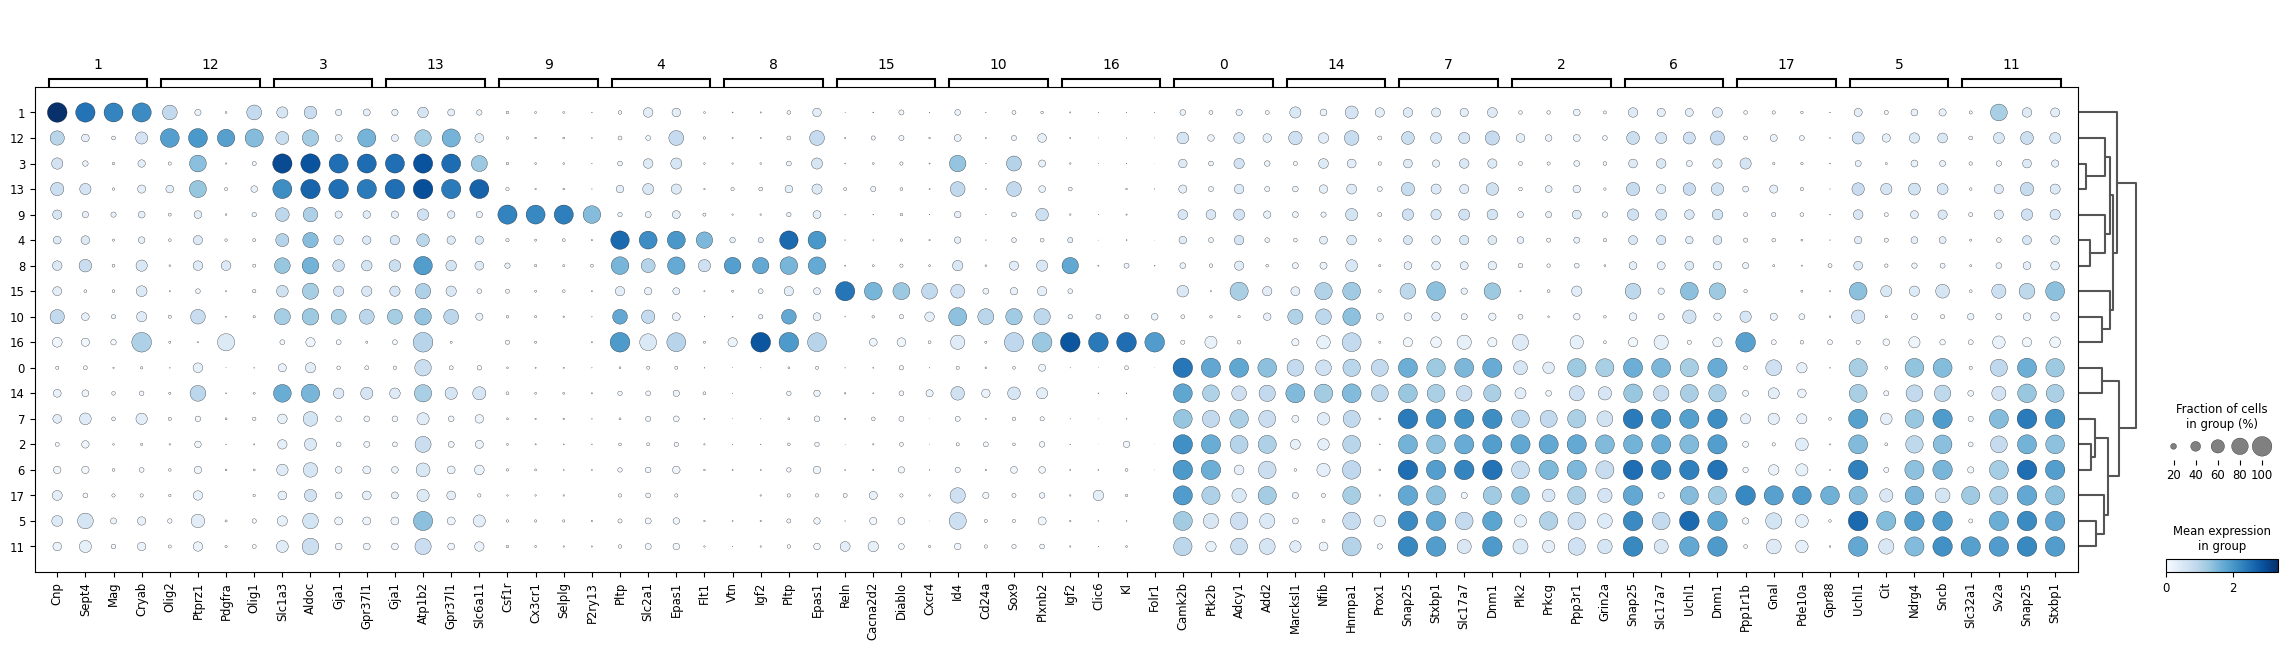

In [6]:
sc.tl.rank_genes_groups(adata, groupby="leiden", use_raw=False)
sc.tl.dendrogram(adata, groupby="leiden")
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden", n_genes=4, cmap="Blues", use_raw=False)

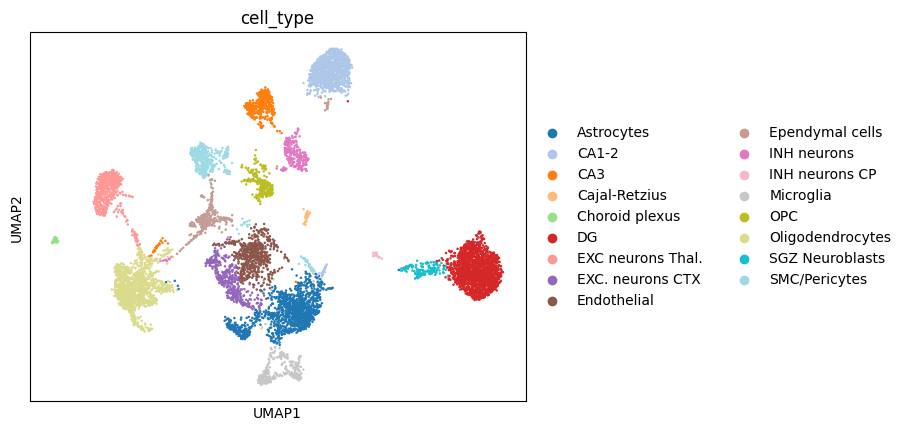

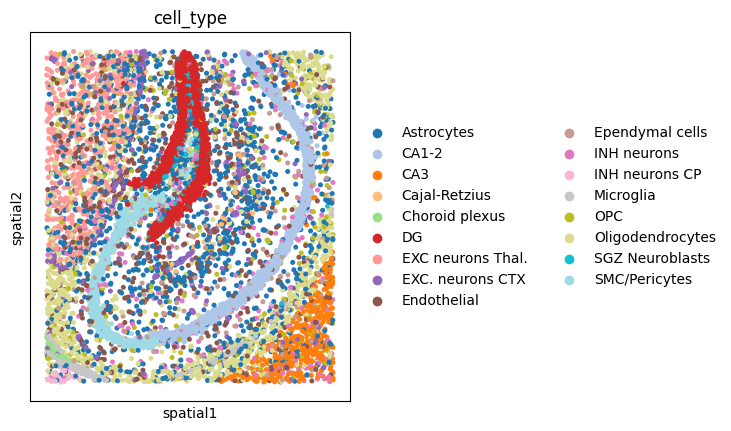

In [7]:
dict_anno = {
    0: "DG",
    1: "Oligodendrocytes",
    2: "CA1-2",
    3: "Astrocytes",
    4: "Endothelial",
    5: "EXC neurons Thal.",
    6: "SMC/Pericytes",
    7: "CA3",
    8: "EXC. neurons CTX",
    9: "Ependymal cells",
    10: "Microglia",
    11: "INH neurons",
    12: "OPC",
    13: "Astrocytes",
    14: "SGZ Neuroblasts",
    15: "Cajal-Retzius",
    16: "Choroid plexus",
    17: "INH neurons CP",
    18: "Oligodendrocytes",
}
# spatialdata element/column names may only contain letters, digits, "_", "." and "-"
adata.obs["cell_type"] = adata.obs["leiden"].astype(int).map(dict_anno)
sc.pl.umap(adata, color="cell_type", palette="tab20")
sc.pl.spatial(adata, spot_size=30, color="cell_type", palette="tab20")

## 4. Segmentation-free analysis

We use `troutpy.pp.segmentation_free_sainsc` to perform segmentation-free analysis, using Sainsc ([Müller-Bötticher et al. 2024](https://onlinelibrary.wiley.com/doi/full/10.1002/smtd.202401123)).
Essentially, all transcripts in the tissue are binned into pixels of the specified `binsize`, in µm. Background signal is filtered based on the `background_filter` parameter and, since spatial datasets are typically sparse at this resolution, the signal is smoothed with a gaussian kernel, adjusted by the `gaussian_kernel_key` parameter.

After binning, filtering and smoothing, we **compute a cosine similarity between each pixel's signature and the cell-type signatures** derived from segmented cells (here, `leiden` clusters). Comparing the distributions of this similarity for pixels inside and outside segmented cells, troutpy derives, for each pixel, a **probability of being uRNA** (`prob_is_urna`). Each transcript then inherits the `closest_cell_type`, `cosine_similarity` and `prob_is_urna` of its pixel.

In [8]:
tp.pp.segmentation_free_sainsc(sdata, binsize=5, celltype_key="leiden", background_filter=0.2, gaussian_kernel_key=2.0)

Since we included in the analysis all transcripts, we can then compare the cosine similarity of the transcripts segmented to cells and those who were not. This will allow us to **classify unassigned RNA in two groups**:
- RNA that  locallyresembles segmented cells (**cell-like**)
- RNA that have a local composition different from segmented cells(**other uRNA**)

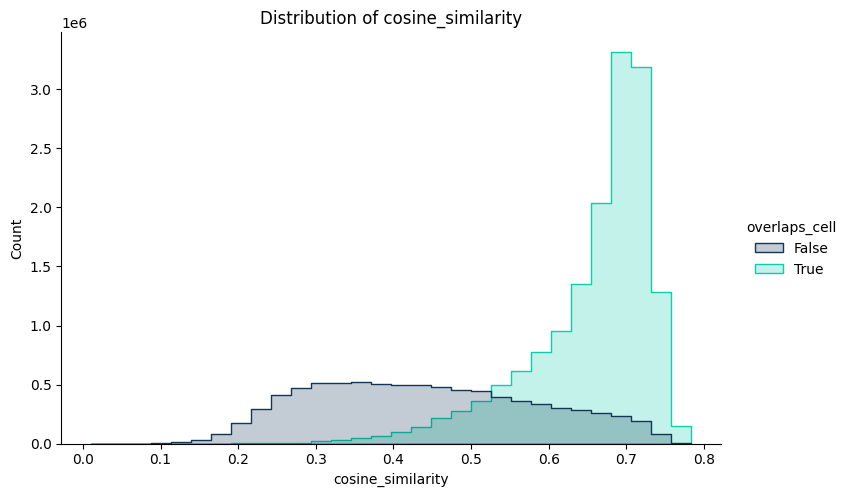

In [9]:
# 3) Histogram of scores
tp.pl.histogram(sdata, x="cosine_similarity", hue="overlaps_cell", palette="troutpy")

Next, we will use the output of segmentation and segmentation-free analysis to identify non-cell-like transcripts. For this, we employ `troutpy.pp.define_urna`. With `method="sainsc"`, extracellular transcripts (uRNA) are defined as those:
- Located outside segmented cells
- With a probability of being uRNA (`prob_is_urna`) above `prob_threshold`

In [10]:
# 4) Define extracellular
tp.pp.define_urna(sdata, layer="transcripts", method="sainsc", prob_threshold=0.5)

Defined 5000262 URNA transcripts using Bayesian P > 0.5


We can visualize how many transcripts considered as non-cell like (here-extracellular), among the ones that were not origially segmented

<Figure size 500x200 with 0 Axes>

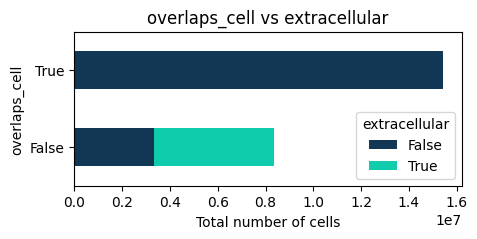

In [11]:
# 5) Crosstab / pie / heatmap
tp.pl.crosstab(sdata, yvar="extracellular", xvar="overlaps_cell", normalize=False, cmap="troutpy", kind="barh", stacked=True, figsize=(5, 2))

## 5. Gene-centric exploration of uRNA compopsition 

### 5.1 Exploring uRNA abundance and proportion

After defining which unassigned RNA does not come from missegmentation, we focus on characterizing the remaining uRNA. First, we will quantify how abundant each uRNA type (each gene) is in the uRNA pool, compared to noise levels. We implemented `troutpy.tl.quantify_overexpression` to identify **genes overexpressed relative to a noise model**.

Essentially, the uRNA counts of the specified control features (here, Xenium's negative control probes and codewords) define the mean of a Poisson noise model. For each gene, the function then computes its uRNA `count`, the log fold change over noise (`logfoldchange_over_noise`) and a Poisson p-value (`p_val_noise`, with BH-corrected `fdr_noise`), and stores them in `sdata["xrna_metadata"].var`.

In [12]:
control_codewords = ["negative_control_probe", "unassigned_codeword", "deprecated_codeword", "genomic_control_probe", "negative_control_codeword"]

tp.tl.quantify_overexpression(sdata, layer="transcripts", codeword_key="codeword_category", control_codewords=control_codewords, gene_key="gene")

We visualize how many genes are present in the uRNA pool over noise levels. As you can see, all control probes are below noise levels (as expected) and some non-control genes are found in the uRNA pool over noise levels

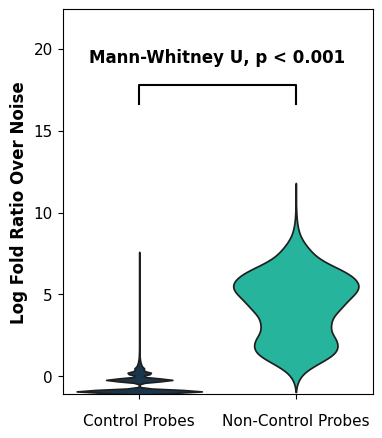

In [13]:
tp.pl.logfoldratio_over_noise(sdata, test_method="auto")

We want to explore which genes are the most enriched ones over noise levels. For this, we visualize a scatter plot with each point representing a single gene. We visualize the uRNA counts in comparison with the  logFoldRatio over noise. We identify that specific genes have a high abundance in the uRNA pool.

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


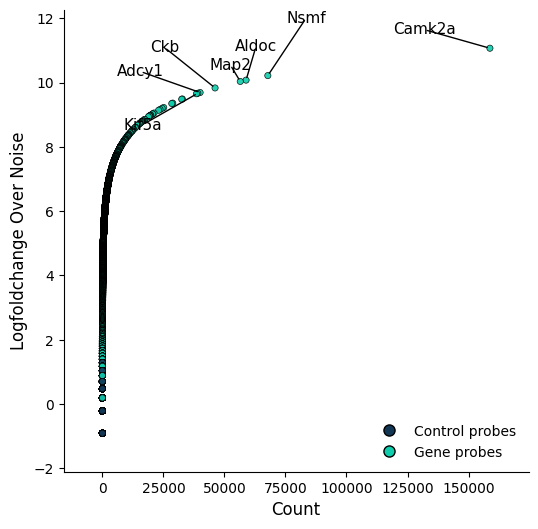

In [14]:
tp.pl.metric_scatter(
    sdata, x="count", y="logfoldchange_over_noise", label_top_n_x=7, label_top_n_y=5, label_bottom_n_x=0, label_bottom_n_y=0, size=20
)

Despite knowing it's contribution to the uRNA pool can be important information, it could simply be that a gene that is highly expressed intracellularly is also highly abundant outside cells due to diverse reasons. Therefore, to complement the uRNA abundance information it will be useful to know also, for each gene, which **proportion of its detected RNA is kept unassigned**. For this we use the function ``tp.tl.extracellular_enrichment``. This will highlight genes that tend to be more detected outside segmented cells. 

In [15]:
tp.tl.extracellular_enrichment(sdata)

We can now visualize both metrics, the uRNA abundance, and the uRNA proportion, side by side across genes. We observe that different genes present different patterns:
- Genes with low uRNA/extracellular proportion (i.e. Aldoa)- are simply highly abundant genes
- Genes with high uRNA proportion but low uRNA abundance- suggest expression patterns in uRNA that is not well captured by segmentation
- Genes with both high uRNA abundance and proportion represent highly expressed genes that are very enriched outside segmented cells. Represent clear patterns

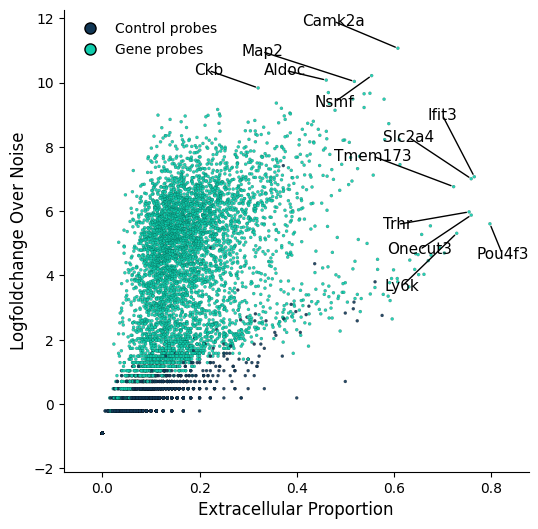

In [16]:
tp.pl.metric_scatter(
    sdata,
    x="extracellular_proportion",
    y="logfoldchange_over_noise",
    label_top_n_x=7,
    label_top_n_y=5,
    label_bottom_n_x=0,
    label_bottom_n_y=0,
    size=5,
    linewidth=0.1,
)

### 5.2 Exploring spatial variability and uRNA patterning

We can also explore other patterns such as the **spatial variability** of individual uRNA genes. For this, we will first bin the uRNA transcripts into bins, same as we did for segmenation-free analysis. We adjust the ``square_size`` parameter to vary the size of squares. Then we will compute moranI. 

In [17]:
tp.pp.aggregate_urna(sdata, gene_key="gene", square_size=50)
tp.tl.spatial_variability(sdata, gene_key="gene", n_neighbors=10)

Extracting gene counts:   0%|          | 0/8740 [00:00<?, ?it/s]

Extracting gene counts:   0%|          | 1/8740 [00:00<15:23,  9.46it/s]

Extracting gene counts:  13%|█▎        | 1171/8740 [00:00<00:01, 6724.49it/s]

Extracting gene counts:  27%|██▋       | 2360/8740 [00:00<00:00, 9052.43it/s]

Extracting gene counts:  41%|████      | 3549/8740 [00:00<00:00, 10162.20it/s]

Extracting gene counts:  54%|█████▍    | 4737/8740 [00:00<00:00, 10777.74it/s]

Extracting gene counts:  68%|██████▊   | 5937/8740 [00:00<00:00, 11190.51it/s]

Extracting gene counts:  82%|████████▏ | 7127/8740 [00:00<00:00, 11420.08it/s]

Extracting gene counts:  95%|█████████▌| 8315/8740 [00:00<00:00, 11563.90it/s]

Extracting gene counts: 100%|██████████| 8740/8740 [00:00<00:00, 10374.31it/s]

We can then identify the most spatially variable genes in the uRNA spectrum. **All gene-specific uRNA-related information**, including uRNA abundance, proportion, spatial variability etc.  **is stored in ``sdata['xrna_metadata'].var``**. We can find the most variable genes, with a higher moranI using:

In [18]:
sdata["xrna_metadata"].var.sort_values(by="moran_I", ascending=False).head(5)

,count,logfoldchange_over_noise,p_val_noise,is_control,fdr_noise,intracellular_proportion,extracellular_proportion,logfoldratio_extracellular,moran_I,moran_pval_norm,moran_var_norm,moran_pval_norm_fdr_bh
gene,,,,,,,,,,,,
Camk2a,158753,11.067128,0.0,False,0.0,0.391753,0.608247,-1.763135,0.740490,0.0,0.000022,0.0
Adcy1,40025,9.689302,0.0,False,0.0,0.534858,0.465142,-1.183528,0.674904,0.0,0.000022,0.0
Map2,56482,10.033712,0.0,False,0.0,0.481326,0.518674,-1.397916,0.621870,0.0,0.000022,0.0
Sptbn2,32497,9.480951,0.0,False,0.0,0.420214,0.579786,-1.645082,0.615416,0.0,0.000022,0.0
Kif5a,39071,9.665179,0.0,False,0.0,0.449355,0.550645,-1.526463,0.608324,0.0,0.000022,0.0


Next we can the distribution of of some of these genes in the space using ``troutpy.pp.spatial_transcripts``. In this case, Adcy1

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Cell Boundaries + Transcripts'}>)

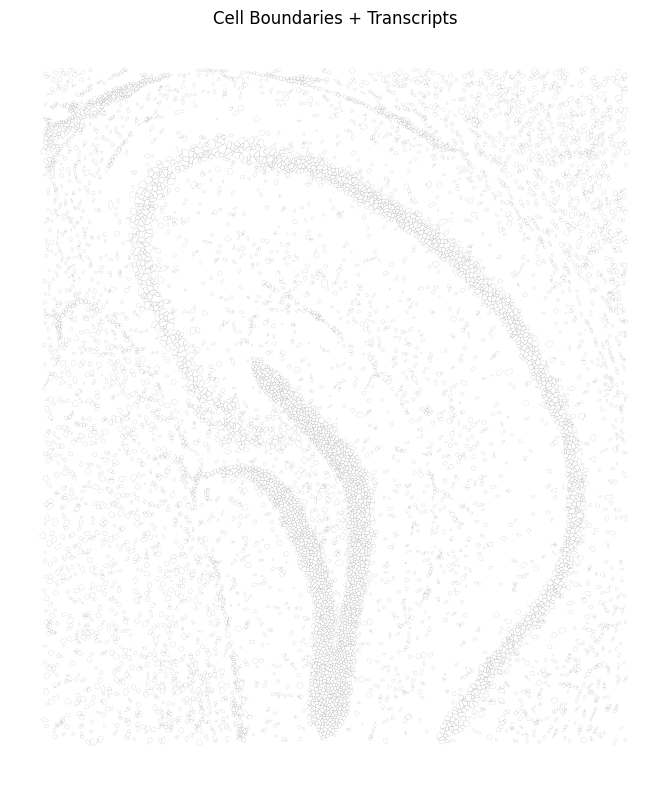

In [19]:
tp.pl.spatial_transcripts(sdata, gene_list=["Adcy1"], scatter_size=2, boundary_linewidth=0.1)

One important part when understanding uRNA is identifying patterns that  differ from those found in segmented cell. For this, we can test for intra-extracellular correlation (extracellular here means uRNA). A requirement for this function is to pre-compute extracellular bins using ``tp.pp.aggregate_urna``

In [20]:
sdata["transcripts"]["gene"] = sdata["transcripts"]["gene"].astype("category")
tp.pp.aggregate_urna(sdata, gene_key="gene", square_size=50)
tp.tl.in_out_correlation(sdata, n_neighbors=20)

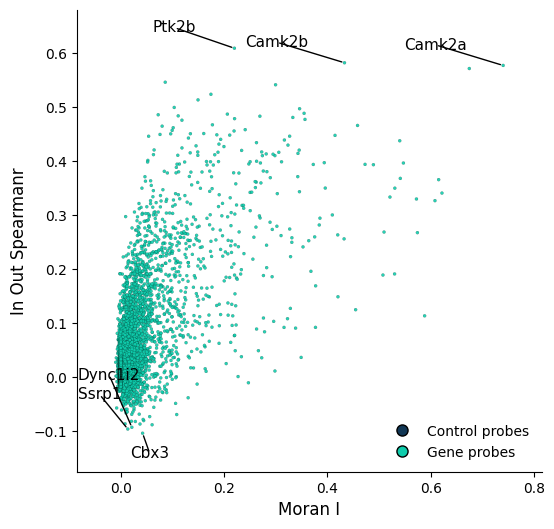

In [21]:
tp.pl.metric_scatter(
    sdata, x="moran_I", y="in_out_spearmanR", label_top_n_x=0, label_top_n_y=3, label_bottom_n_x=0, label_bottom_n_y=3, size=5, linewidth=0.1
)

We can visualize how expression in and out cells compare, fr one of the genes with highest spearman's intracellular-extracellular correlation

(<Figure size 800x800 with 1 Axes>,
 <Axes: title={'center': 'Cell Boundaries + Transcripts'}>)

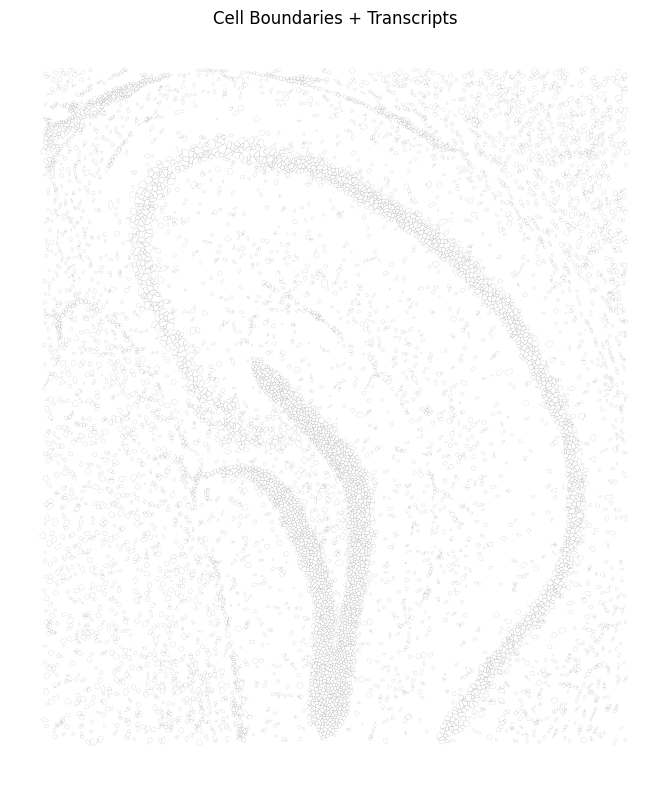

In [22]:
tp.pl.spatial_transcripts(sdata, gene_list=["Ptk2b"], scatter_size=2, boundary_linewidth=0.1)

### 5.3 Filtering uRNA genes

For some analyses, we might want to only keep part of the genes, the ones showing relevant characteristics. For instance, we might want to only keep genes clearly found above noise (`max_p_val_noise`, `min_logfoldratio_over_noise`) and that are not control probes (`control_probe=False`). This we can do with:

In [23]:
tp.pp.filter_urna(sdata, gene_key="gene", min_logfoldratio_over_noise=7, max_p_val_noise=0.05, control_probe=False)

In [24]:
sdata["xrna_metadata"].var.shape

(376, 14)

## 6. Identifying uRNAs source

For the selected genes, we identify each uRNA's source. Our source score represents the probability of each cell type being the origin of each uRNA, combining **physical proximity** to candidate cells (with an exponential distance decay, `lmbda`) and **expression context**: how well each candidate cell's expression matches the genes found in the uRNA's local neighbourhood.

The size of that neighbourhood adapts to the local uRNA density, so we first compute, for each transcript, how enriched its local density is over a random background with `tp.tl.density_similarity` (stored as `enrichment_over_random`, together with an `enrichment_class`):

In [25]:
tp.tl.density_similarity(sdata, radius=10)

Calculating local counts for 4706473 transcripts...


Subsampling 500 cells to build likelihood distribution...


--- Analysis Complete ---
Expected Background Count: 437.44
Cell Model Median Count: 2604.00


SpatialData object, with associated Zarr store: data.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 9300, 8049), (5, 4650, 4025), (5, 2325, 2012), (5, 1162, 1006), (5, 581, 502)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
│     └── 'nucleus_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
├── Points
│     ├── 'extracellular_transcripts': DataFrame with shape: (<Delayed>, 19) (3D points)
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 23) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (9289, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (9191, 2) (2D shapes)
│     ├── 'grid_squares': GeoDataFrame shape: (1400, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (9249, 1) (2D shapes)
└── Tables
      ├── 'segmentation_free_table': AnnData (1400, 376)
      ├── 'table': AnnData (9185, 4886)
      

We then use `tp.tl.adaptative_source_score_optimized` to score every uRNA against the cells around it (within `max_dist` µm):

In [26]:
tp.tl.adaptative_source_score_optimized(sdata, cell_type_col="cell_type", max_dist=100, lmbda=0.1)

Aligning data and cleaning IDs...


Building global spatial shell...


Building transcript spatial tree...


Processing 4722153 transcripts in 48 chunks...


  0%|          | 0/48 [00:00<?, ?it/s]

...

100%|██████████| 48/48 [05:55<00:00,  6.53s/it]

100%|██████████| 48/48 [05:55<00:00,  7.40s/it]

Reconstructing results into AnnData...


Updating xrna_metadata and cell scores...


Success: 4705680 transcripts assigned.


The resulting source score is stored in `sdata["source_score"]`, in AnnData format, where `.X` represents the source score of each uRNA transcript (obs) across cell types (var). The most likely source cell (`predicted_parent`), its score (`assignment_score`) and the distance to it (`distance_to_source`) are stored in `.obs`.

In [27]:
sdata["source_score"]

AnnData object with n_obs × n_vars = 4722153 × 17
    obs: 'gene', 'predicted_parent', 'assignment_score', 'distance_to_source'
    obsm: 'spatial'

### 6.1 Assesing diffusion

We can use the source score information for several purposes. First, we can assess wether, for each gene, the distances in relation to their closest potential source cells follows a rayleigh distribution, which would suggest diffusion as an origin of the pattern.

In [28]:
tp.tl.assess_diffusion(sdata, gene_key="gene", distance_key="distance_to_source")

--- Diffusion Analysis Debug ---


Initial transcripts: 11194330


Transcripts passing filters: 11194330


Transcripts shared with source_score: 4722153


SUCCESS: Statistics added for 376 genes.


We can visualize the output of our diffusion test. For each gene, the y axis shows the -log p-value of a Kolmogorov-Smirnov test comparing the measured distances to the source cell with a fitted Rayleigh distribution (the expected distribution under 2D diffusion), and the x axis the mean distance of its uRNAs to their potential source. The red line indicates significance: genes above it have a distribution of distances different from a diffusion pattern.

As observed, in this example all genes exhibit distributions that do not match diffusion patterns.

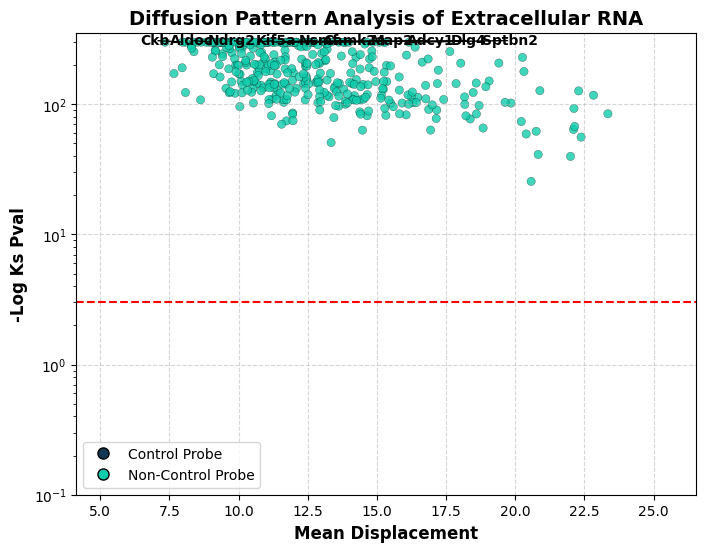

In [29]:
tp.pl.diffusion_results(sdata, label_top_n_y=10, y_logscale=True)

We can also visualize the distribution of distances and the fitted Rayleigh curves for individual genes: a gene-specific fit, using only the uRNAs of the gene of interest (used for the KS test), and a global fit, using all genes. In this example, Camk2b uRNAs are enriched at shorter distances from their source than expected from diffusion, with a long tail of distant uRNAs, which results in a very low p-value.

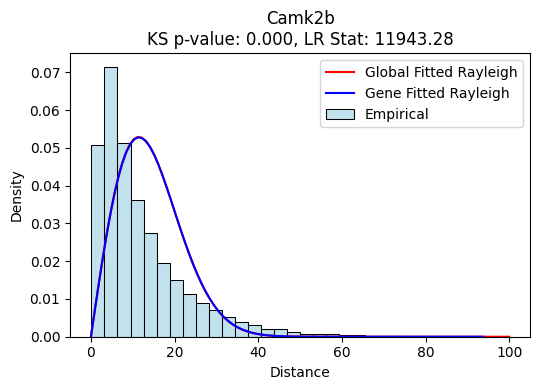

In [30]:
tp.pl.gene_distribution_from_source(sdata, ["Camk2b"], distance_key="distance_to_source")

We can also visualize, for each gene, their potential uRNAs source based on cell type expression and physical proximity

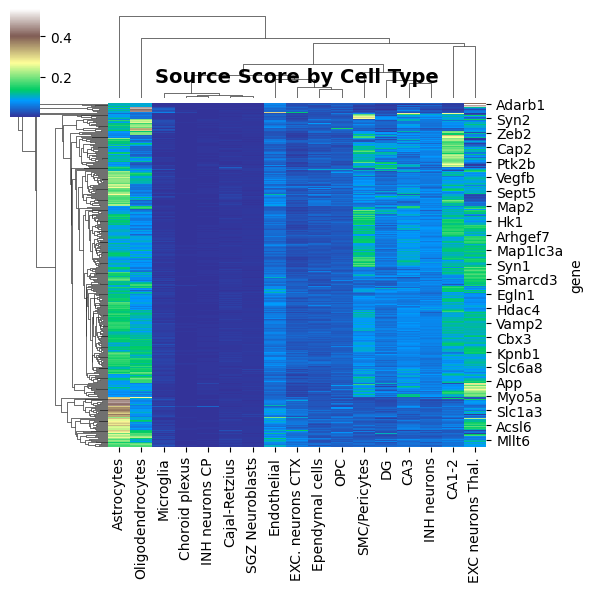

In [31]:
tp.pl.source_score_by_celltype(sdata, figsize=(6, 6), cmap="terrain")

### 6.2. Cell-specific uRNAs source score

From our source score analysis, we also obtain a per-cell uRNA source score, stored in `sdata["table"].obs` as a column called `urna_source_score`. This score represents, for each cell, how many uRNAs from the uRNA pool can be attributed to it. We can simply visualize the scores for each cell:

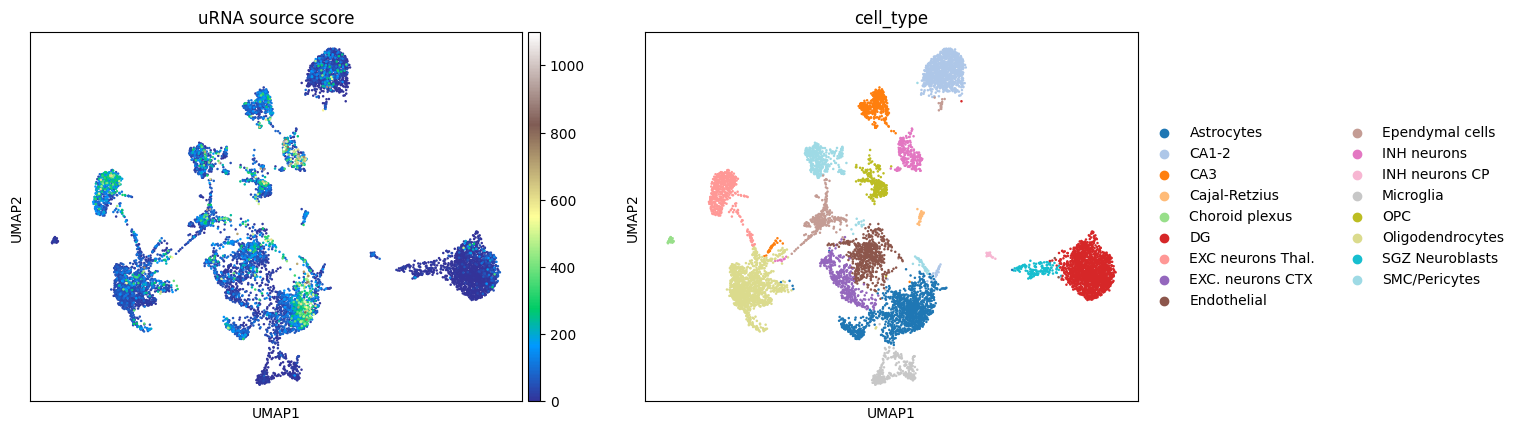

In [32]:
sc.pl.umap(sdata["table"], color=["urna_source_score", "cell_type"], cmap="terrain", title="uRNA source score", vmax="p99.995")

We can also visualize, in space, which cells each uRNA is attributed to with `tp.pl.spatial_transcripts_source`. uRNA transcripts with an `assignment_score` above `min_score` are colored by the cell type of their predicted source cell, and `show_edges=True` draws a line between each uRNA and its source:

(<Figure size 2500x2500 with 1 Axes>,
 <Axes: title={'center': 'Global Connectivity | Boundaries + Expression Channels | Subsetting for Camk2b'}>)

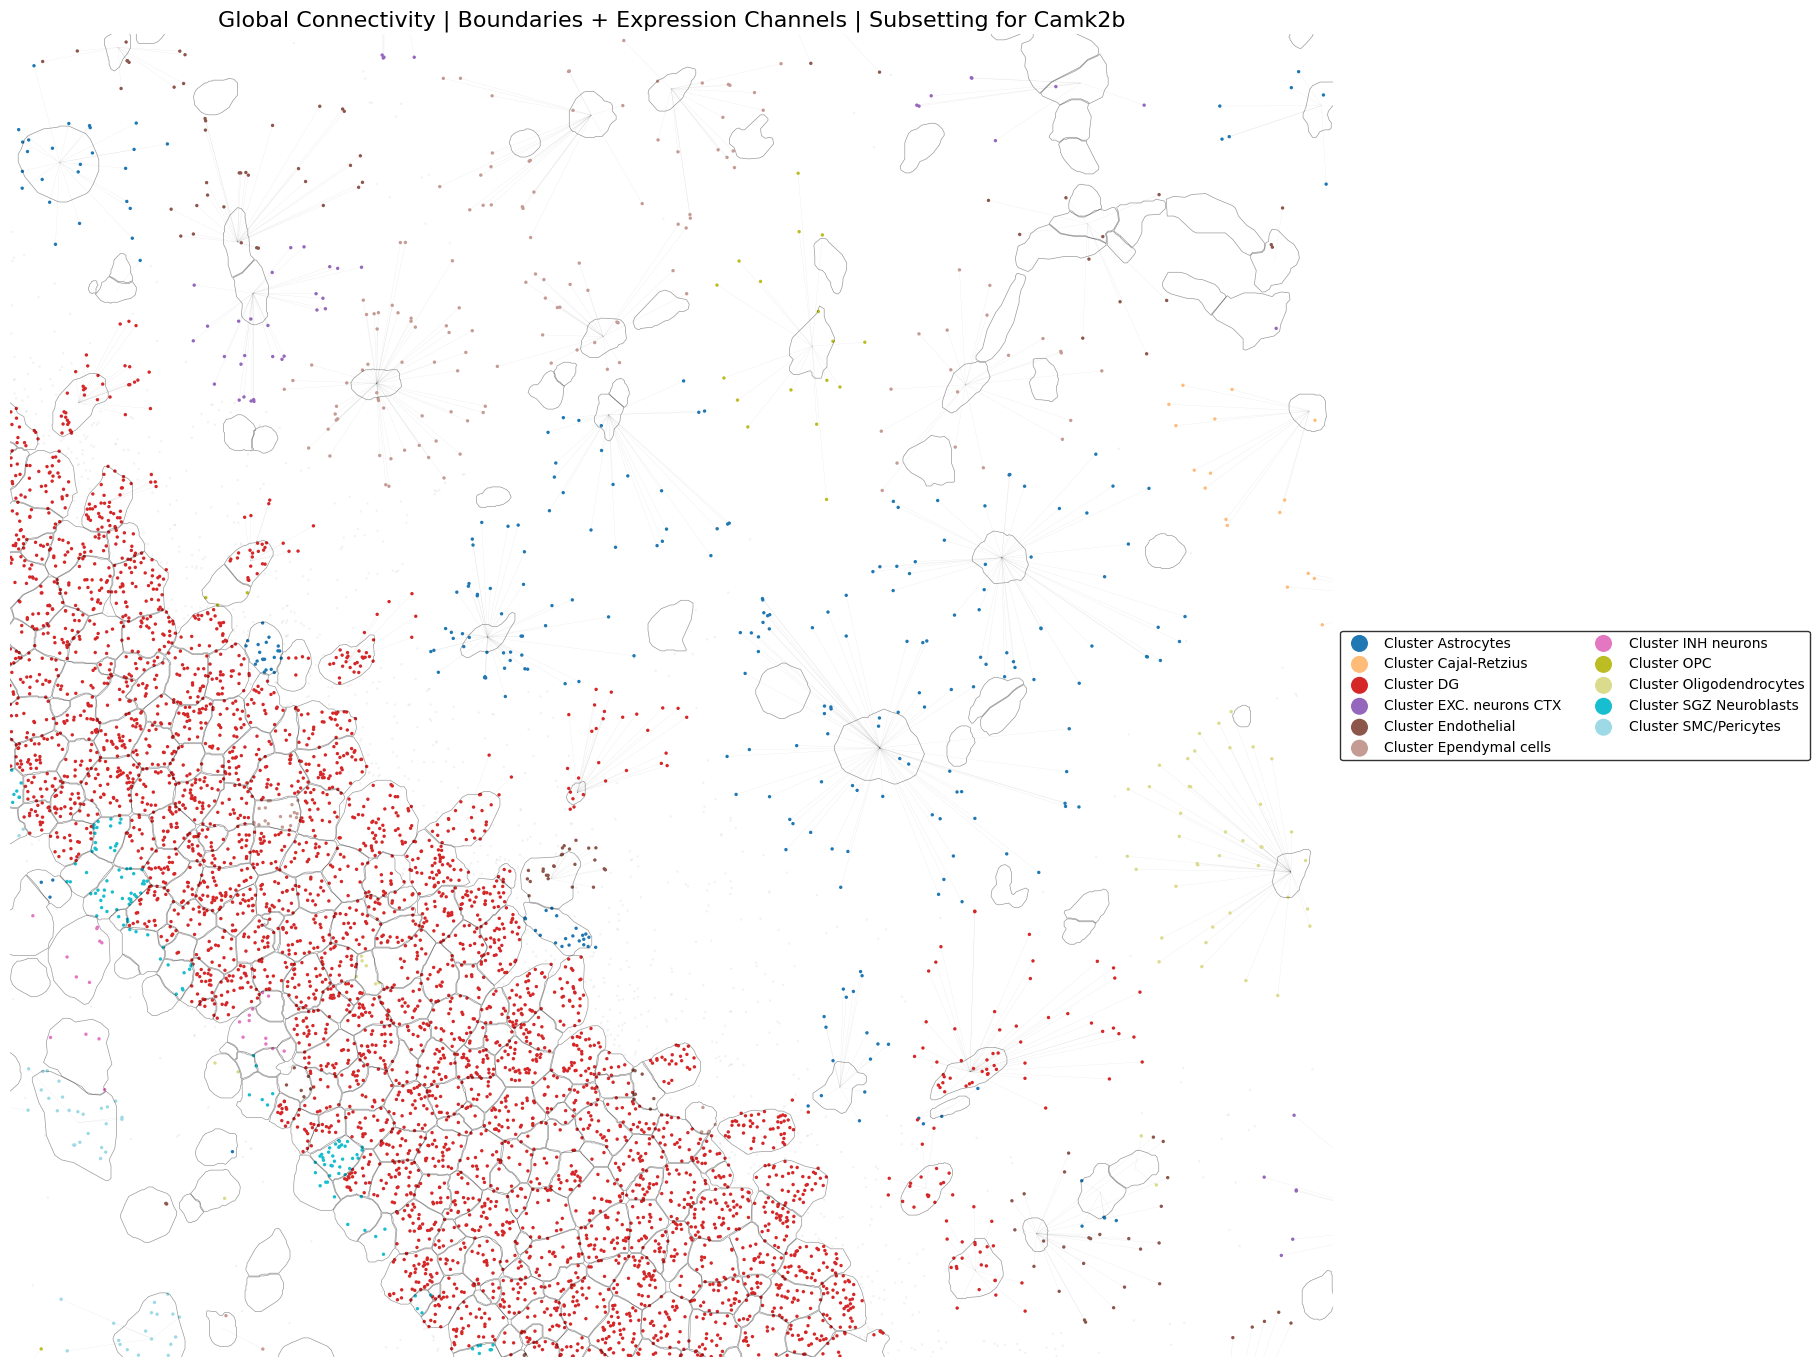

In [33]:
tp.pl.spatial_transcripts_source(
    sdata,
    cell_color_key="cell_type",
    extra_color_key="cell_type",
    gene_list=["Camk2b"],
    use_roi=True,
    roi=(4800, 5100, 1800, 2100),
    point_size=3,
    show_edges=True,
)

## 7. Target scores and cell-cell contacts inferred from uRNA

Complementary to the source, we can also compute a **target score** with `tp.tl.compute_target_score`: for each uRNA transcript, the probability of each cell type being its receiver, based on proximity to nearby cells. Results are stored in `sdata["target_score"]`.

In [34]:
tp.tl.compute_target_score(sdata, layer="transcripts", lambda_decay=0.1, copy=False, celltype_key="cell_type", gene_key="gene")

Computing target scores for 2,910,682 transcripts in batches of 100000...


  0%|          | 0/30 [00:00<?, ?it/s]

  3%|▎         | 1/30 [00:01<00:35,  1.24s/it]

  7%|▋         | 2/30 [00:02<00:33,  1.18s/it]

 10%|█         | 3/30 [00:03<00:31,  1.16s/it]

...

 90%|█████████ | 27/30 [00:31<00:03,  1.13s/it]

 93%|█████████▎| 28/30 [00:32<00:02,  1.13s/it]

 97%|█████████▋| 29/30 [00:33<00:01,  1.14s/it]

100%|██████████| 30/30 [00:33<00:00,  1.20it/s]

100%|██████████| 30/30 [00:33<00:00,  1.11s/it]

We can use this information to compute enhanced cell-cell contacts. The idea is that non-technical uRNA must represent RNA from protrusions and, thus, it can be used as a proxy of cell-cell contact: a uRNA links its source cell to its target cell, even if their cell bodies are not adjacent.

In [35]:
tp.tl.cell_contacts_with_urna_sources(sdata, spatial_key="spatial", cell_type_key="cell_type", distance=20)

We can visualize the combined cell-cell contacts between paired cell types. This includes both proximity between cell bodies and uRNA-mediate cell-cell contacts

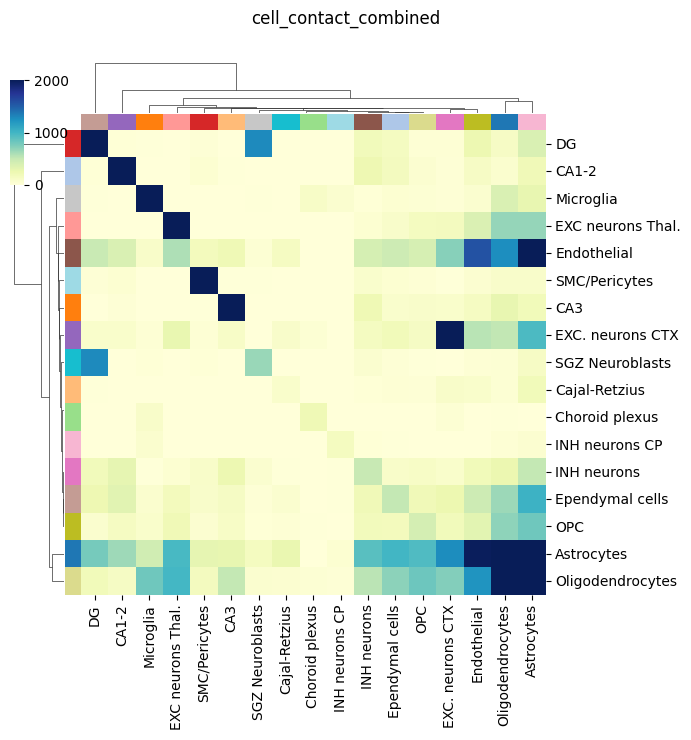

In [36]:
tp.pl.cell_type_contacts(sdata, celltype_key="cell_type", figsize=(7, 7), dendrogram_ratio=0.1, cmap="YlGnBu", key="cell_contact_combined", vmax=2000)

We can finally also visualize only the cell-cell contacts inferred from uRNA. They are not as many as the cell-body ones, but they are clearly enriched for some cell types, including endothelial cells, oligodendrocytes and astrocytes. These cell types are known to present abundant but short protrusions, which are expected to be captured by this approach. Furthermore, this metric is clearly asymmetrical, since cell proximity is only considered for a target cell (receiver, columns) if a certain uRNA with a defined source (sender, rows) is found in its vicinity.

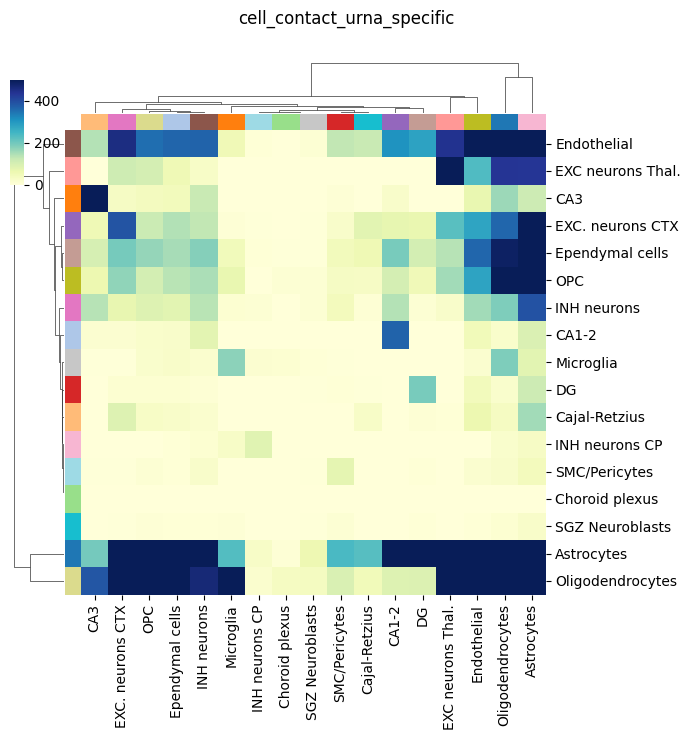

In [37]:
tp.pl.cell_type_contacts(
    sdata, celltype_key="cell_type", figsize=(7, 7), dendrogram_ratio=0.1, cmap="YlGnBu", key="cell_contact_urna_specific", vmax=500
)

## 8. Correcting segmented-cell expression for uRNA spillover

Protrusions are long and thin, so some protrusion-derived transcripts do not land in empty space but **inside the segmentation mask of a neighbouring cell**. Segmentation-based counting then silently attributes them to the wrong cell. troutpy provides several complementary ways to detect and correct this.

### 8.1 Flagging intracellular spillover

`tp.tl.flag_intracellular_spillover` reuses the segmentation-free output from section 4: an intracellular transcript is flagged when its local signature looks extracellular-like (`prob_is_urna > prob_threshold`) **and** its `closest_cell_type` differs from the type of the cell it sits in. Since `closest_cell_type` was computed against `leiden` signatures, we compare against `leiden` here too.

In [38]:
spillover = tp.tl.flag_intracellular_spillover(sdata, prob_threshold=0.5, cell_type_col="leiden")
spillover.head()

Flagged 62505 / 6487857 intracellular transcripts as likely spillover (prob_threshold=0.5).


,gene,own_cell_id,own_cell_type,predicted_true_type,prob_is_urna,is_spillover
2,Csde1,emjeegjb-1,2,2,0.021051,False
3,Snrpn,klmhbfnl-1,2,2,0.018032,False
5,Dnm1,lkefnhid-1,5,5,0.018076,False
8,Snrpn,kliobiin-1,2,2,0.018014,False
9,Csde1,egocomdb-1,12,12,0.211424,False


Flagged transcripts can then be removed from the receiving cell's counts with `tp.tl.decontaminate_cell_expression`, which writes a corrected copy of the `raw` layer to `sdata["table"].layers["decontaminated"]`. (`tp.tl.credit_spillover_to_source` can, in turn, add them to the extracellular tally of their predicted source cell type.)

In [39]:
tp.tl.decontaminate_cell_expression(sdata, spillover, layer_key="raw", output_layer="decontaminated")

Decontaminated 'decontaminated': applied to 47683 (cell, gene) pairs, skipped 0 (id/gene not found).


SpatialData object, with associated Zarr store: data.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (5, 9300, 8049), (5, 4650, 4025), (5, 2325, 2012), (5, 1162, 1006), (5, 581, 502)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
│     └── 'nucleus_labels': DataTree[yx] (9300, 8049), (4650, 4025), (2325, 2012), (1162, 1006), (581, 502)
├── Points
│     ├── 'extracellular_transcripts': DataFrame with shape: (<Delayed>, 19) (3D points)
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 23) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (9289, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (9191, 2) (2D shapes)
│     ├── 'grid_squares': GeoDataFrame shape: (1400, 1) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (9249, 1) (2D shapes)
└── Tables
      ├── 'segmentation_free_table': AnnData (1400, 376)
      ├── 'source_score': AnnData (4722153, 17

### 8.2 Subtracting local uRNA background

A simpler, independent correction is `tp.tl.subtract_local_urna_background`: for each cell and gene, it estimates how many transcripts would be expected inside the cell's footprint purely from the **local uRNA density** of that gene (in an annulus between `inner_radius` and `radius` around the cell), and subtracts that expected background from the cell's counts. Removed counts are credited back to the gene's uRNA `count` in `sdata["xrna_metadata"].var`.

In [40]:
tp.tl.subtract_local_urna_background(sdata, radius=100, inner_radius=10, raw_layer="raw", output_layer="decontaminated_density")

Estimating local uRNA background for 9185 cells (annulus 10-100), using real segmentation areas...


Local background subtraction:   0%|          | 0/9185 [00:00<?, ?it/s]

Local background subtraction:   0%|          | 3/9185 [00:00<05:19, 28.74it/s]

Local background subtraction:   0%|          | 8/9185 [00:00<03:55, 38.96it/s]

Local background subtraction:   0%|          | 15/9185 [00:00<02:56, 51.94it/s]

...

Local background subtraction: 100%|█████████▉| 9171/9185 [03:40<00:00, 38.66it/s]

Local background subtraction: 100%|█████████▉| 9176/9185 [03:40<00:00, 41.13it/s]

Local background subtraction: 100%|█████████▉| 9182/9185 [03:40<00:00, 44.71it/s]

Local background subtraction: 100%|██████████| 9185/9185 [03:40<00:00, 41.67it/s]

Local background subtraction: removed 399494.1 counts total across 9185 cells (0 cells skipped for insufficient shape data).


In [41]:
adata = sdata["table"]
for layer in ["raw", "decontaminated", "decontaminated_density"]:
    print(f"{layer:>24}: {adata.layers[layer].sum():,.0f} counts")

                     raw: 11,281,043 counts
          decontaminated: 11,221,590 counts
  decontaminated_density: 10,881,549 counts


Finally, `tp.tl.iterative_soft_decontamination` implements a more thorough, iterative approach: it gives every intracellular transcript a continuous contamination weight (`tp.tl.generalized_source_score`), moves that weight from the cell it sits in to its most likely true source cell (`tp.tl.apply_soft_decontamination`), re-runs the uRNA source scoring against the corrected expression, and repeats until convergence. Since it updates `sdata["table"].X` in place and is computationally more demanding, it is not run in this tutorial:

```python
convergence = tp.tl.iterative_soft_decontamination(sdata, n_iter=5, raw_layer="raw", extracellular_score_kwargs={"cell_type_col": "cell_type"})
```

We will finally save the final object for our internal use

In [42]:
sdata.write("./data_filt.zarr")  # please modify the path to your convenience

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside data_filt.zarr). Please see the documentation of `is_self_contained()` to understand the
         implications of working with SpatialData objects that are not self-contained.                             


INFO     The Zarr backing store has been changed from data.zarr the new file path: data_filt.zarr                  
